In [1]:
import sys
import os
import io
import contextlib

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs, extract_history,
    plot_all_diagnostics, get_optimizer_colors,
    DIAG_KEYS_METRIC_SCALE, DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE, DIAG_KEYS_TRAINING, DIAG_KEYS_OFFDIAG,
    TASK_CONFIGS,
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

BACKEND = "local"
RESULTS_DIR = os.path.join('..', '..', 'results')

DIAG_KEYS = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING + DIAG_KEYS_OFFDIAG
)


def _quiet(fn, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)


def show_diagnostics(task_key):
    """Load and plot diagnostics for a sweep task."""
    cfg = TASK_CONFIGS[task_key]
    colors = get_optimizer_colors(cfg['optimizers'])
    best_runs = _quiet(load_best_runs,
        backend=BACKEND, optimizers=cfg['optimizers'],
        task_tag=cfg['task_tag'], results_dir=RESULTS_DIR,
        metric_key=cfg['metric_key'], direction=cfg['direction'],
        sort_metric=cfg['sort_metric'], sort_order=cfg['sort_order'],
        iteration=cfg['iteration'],
    )
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix=cfg['display_name'], colors=colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print(f"No diagnostic data for {cfg['display_name']}.")

# Optimizer Diagnostics

Internal state diagnostics (requires `--diagnostics` flag during sweep).

## MNIST MLP

In [2]:
show_diagnostics("mnist_mlp")

  [skip] No data for requested keys in: MNIST MLP: Training-Level Diagnostics
  [skip] No data for requested keys in: MNIST MLP: Metric Scale (r, v_hat, metric_ema)
  [skip] No data for requested keys in: MNIST MLP: Learnable Metric Diagnostics
  [skip] No data for requested keys in: MNIST MLP: Curvature-Aware Diagnostics
  [skip] No data for requested keys in: MNIST MLP: Off-Diagonal (Woodbury) Diagnostics
  [skip] No effective LR data for: MNIST MLP: Effective LR Comparison
No diagnostic data for MNIST MLP.


## CIFAR-10 ResNet-18

In [3]:
show_diagnostics("cifar10_resnet18")

  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Training-Level Diagnostics
  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Metric Scale (r, v_hat, metric_ema)
  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Learnable Metric Diagnostics
  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Curvature-Aware Diagnostics
  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Off-Diagonal (Woodbury) Diagnostics
  [skip] No diagnostic data for: CIFAR-10 ResNet-18: Effective LR Comparison
No diagnostic data for CIFAR-10 ResNet-18.


## Shakespeare MiniGPT

In [4]:
show_diagnostics("shakespeare_minigpt")

  [skip] No data for requested keys in: Shakespeare MiniGPT: Training-Level Diagnostics
  [skip] No data for requested keys in: Shakespeare MiniGPT: Metric Scale (r, v_hat, metric_ema)
  [skip] No data for requested keys in: Shakespeare MiniGPT: Learnable Metric Diagnostics
  [skip] No data for requested keys in: Shakespeare MiniGPT: Curvature-Aware Diagnostics
  [skip] No data for requested keys in: Shakespeare MiniGPT: Off-Diagonal (Woodbury) Diagnostics
  [skip] No effective LR data for: Shakespeare MiniGPT: Effective LR Comparison
No diagnostic data for Shakespeare MiniGPT.


## Regression

In [5]:
show_diagnostics("regression")

  [skip] No diagnostic data for: Regression: Training-Level Diagnostics
  [skip] No diagnostic data for: Regression: Metric Scale (r, v_hat, metric_ema)
  [skip] No diagnostic data for: Regression: Learnable Metric Diagnostics
  [skip] No diagnostic data for: Regression: Curvature-Aware Diagnostics
  [skip] No diagnostic data for: Regression: Off-Diagonal (Woodbury) Diagnostics
  [skip] No diagnostic data for: Regression: Effective LR Comparison
No diagnostic data for Regression.


## Small Examples

In [6]:
FUNCTIONS = ['beale', 'rosenbrock', 'himmelblau', 'ackley', 'rastrigin', 'styblinski_tang']
ITERATION_SE = 4

if BACKEND == "local":
    _avail = set()
    for fn in FUNCTIONS:
        td = os.path.join(RESULTS_DIR, f"small_examples_{fn}")
        if os.path.isdir(td):
            _avail.update(d for d in os.listdir(td) if os.path.isdir(os.path.join(td, d)))
    SE_OPTIMIZERS = sorted(_avail)
else:
    SE_OPTIMIZERS = ['adam', 'sgd_learn_diag', 'sgd_learn_diag_curv']

se_colors = get_optimizer_colors(SE_OPTIMIZERS)

### Beale

  [skip] No data for requested keys in: beale: Off-Diagonal (Woodbury) Diagnostics


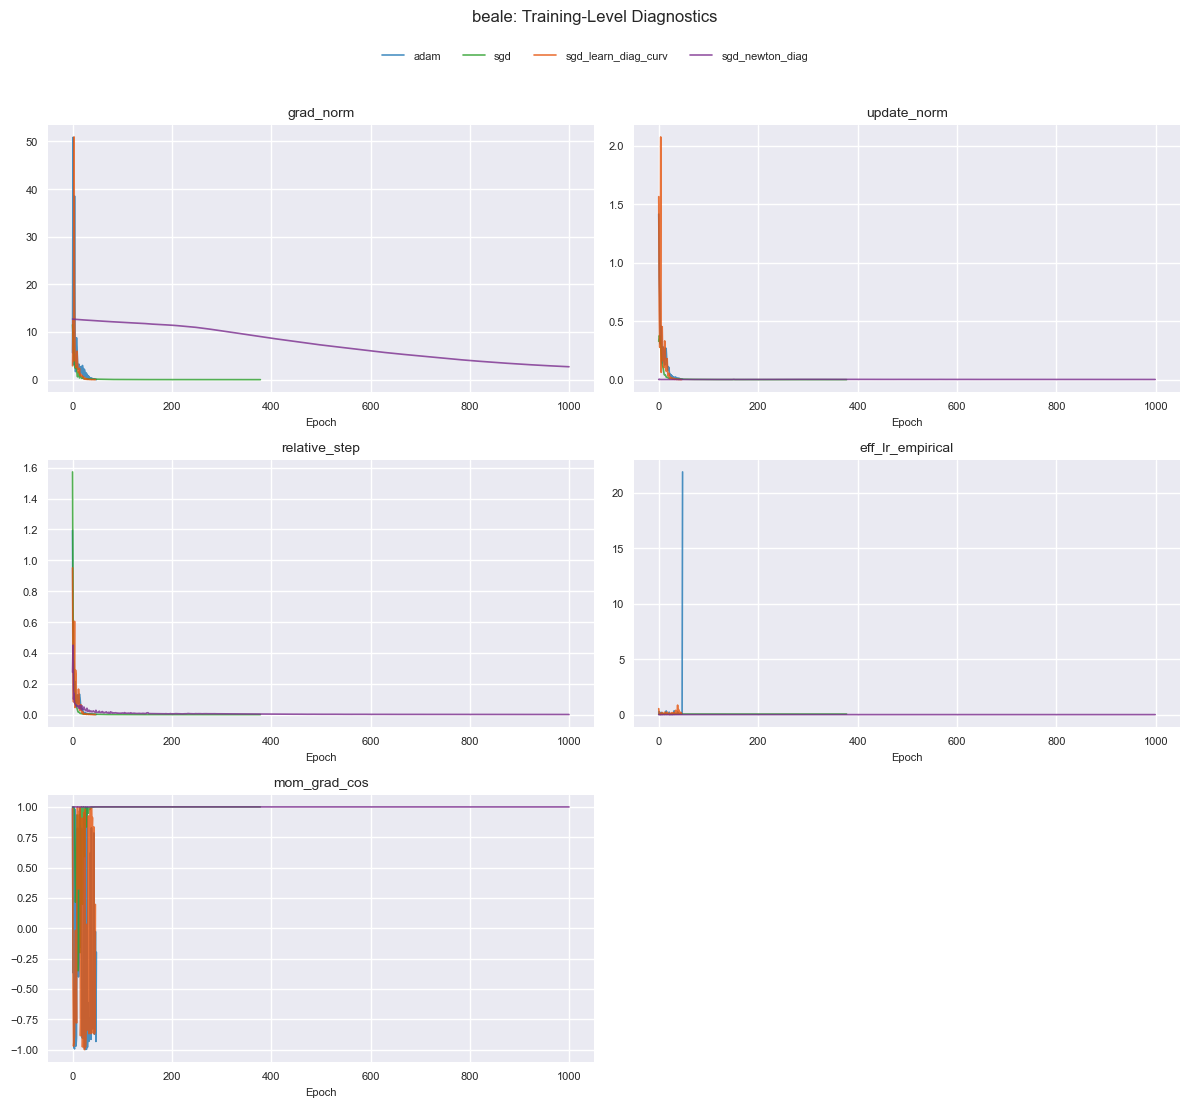

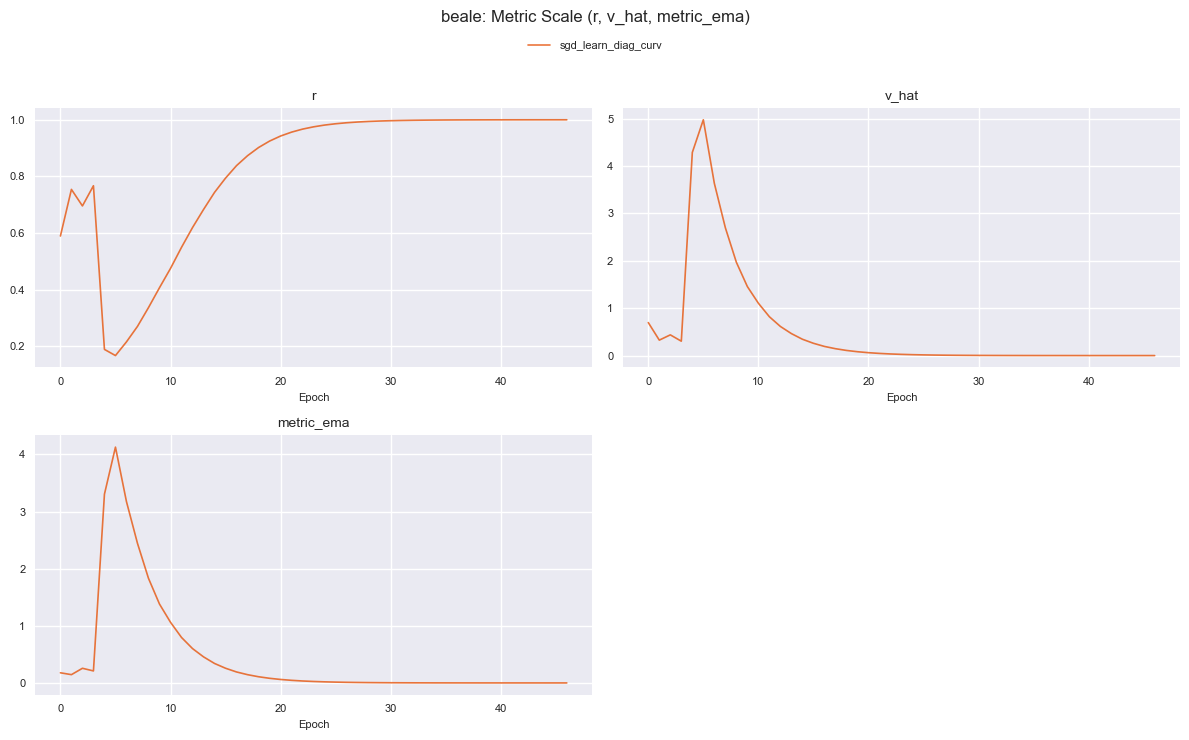

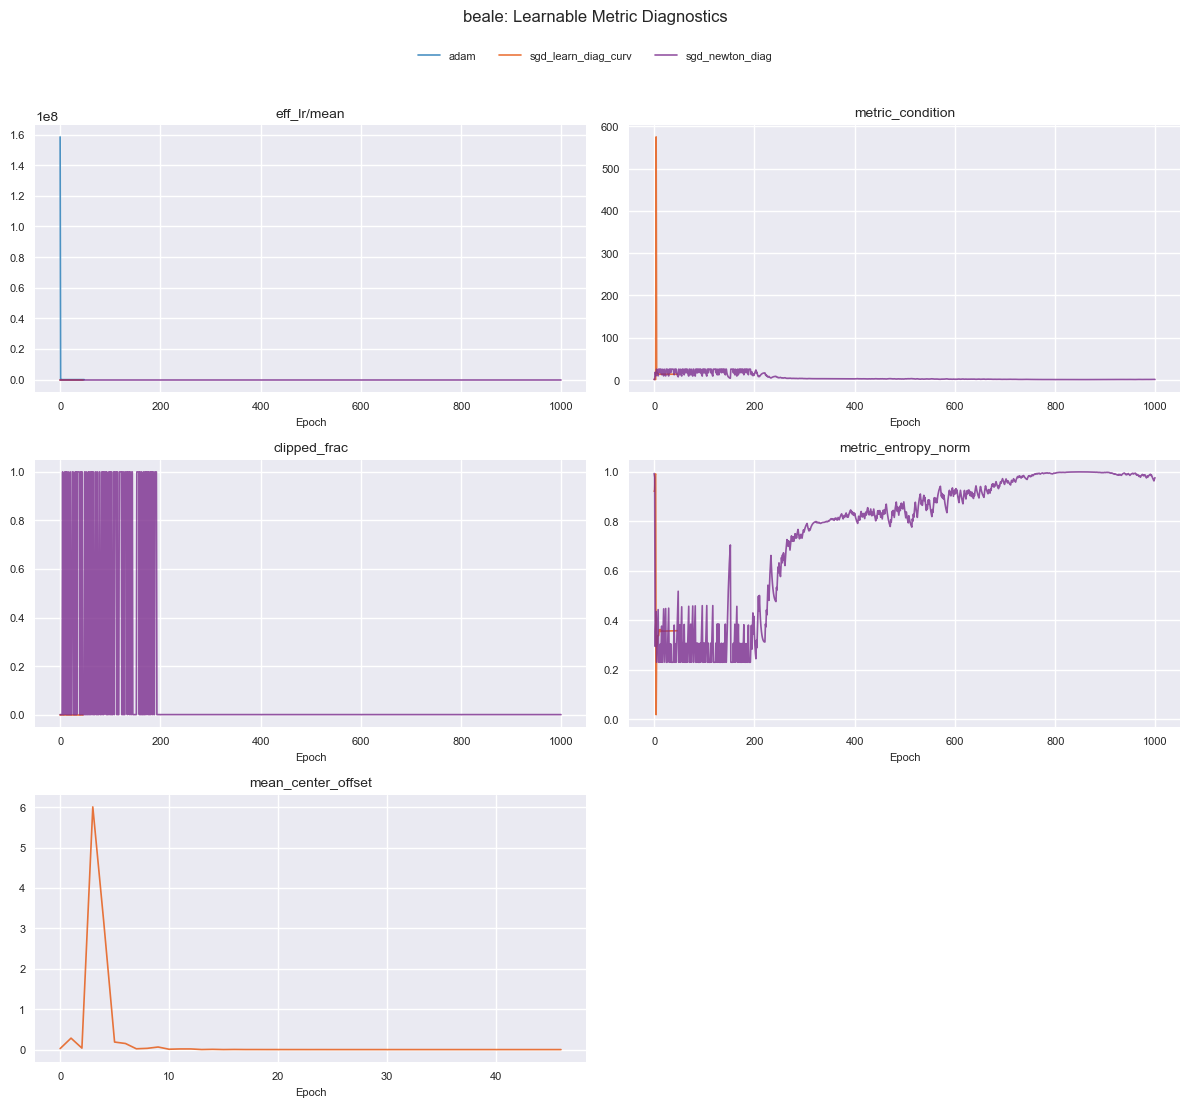

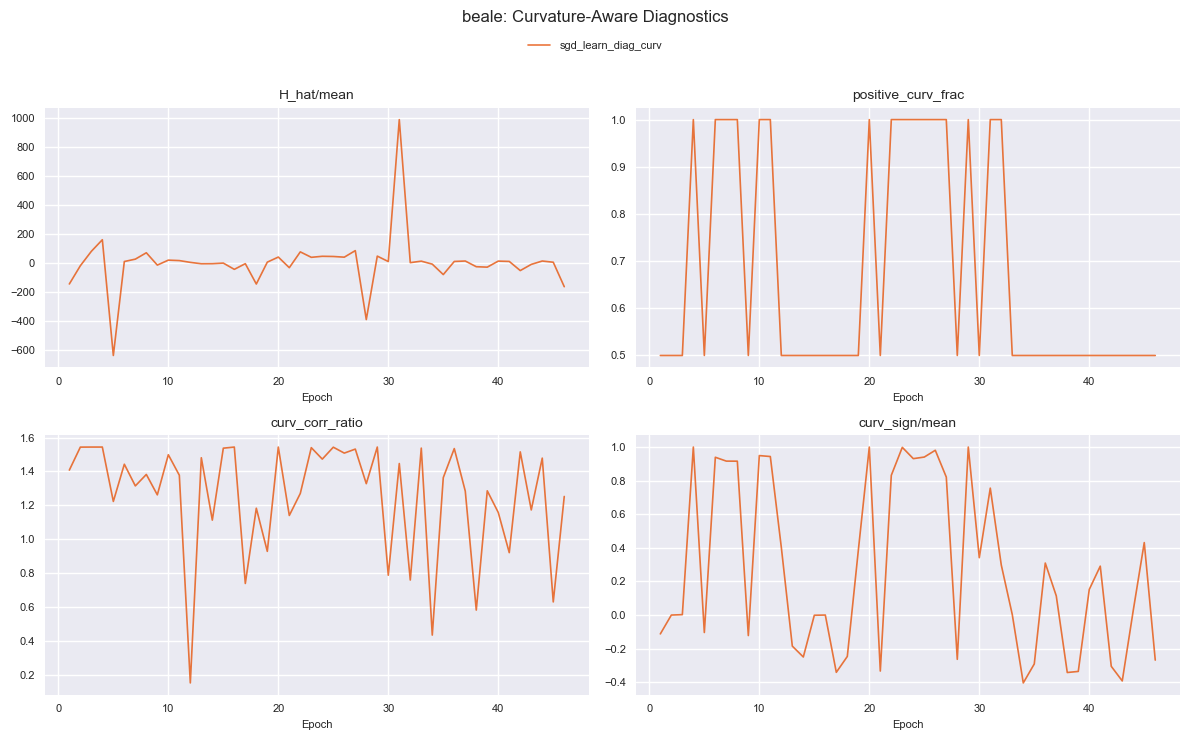

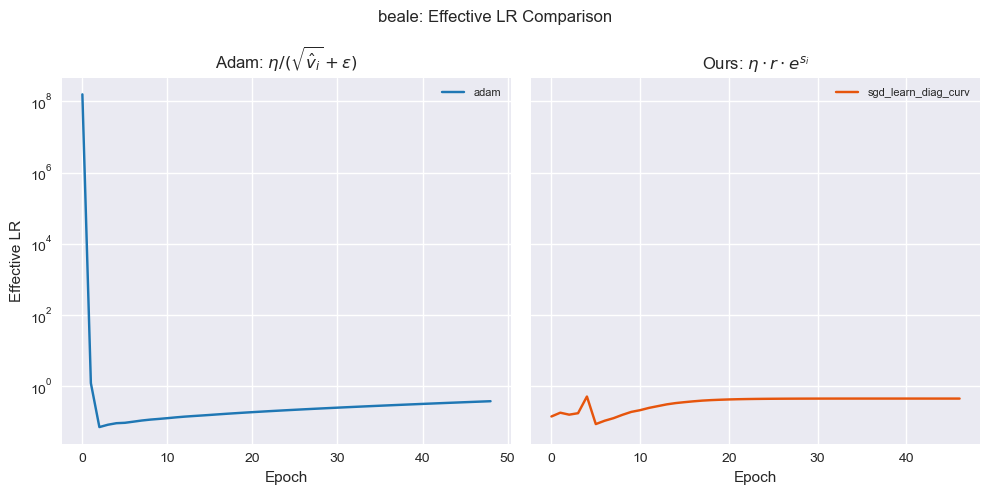

In [7]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_beale", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="beale", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for beale.")

### Rosenbrock

  [skip] No data for requested keys in: rosenbrock: Off-Diagonal (Woodbury) Diagnostics


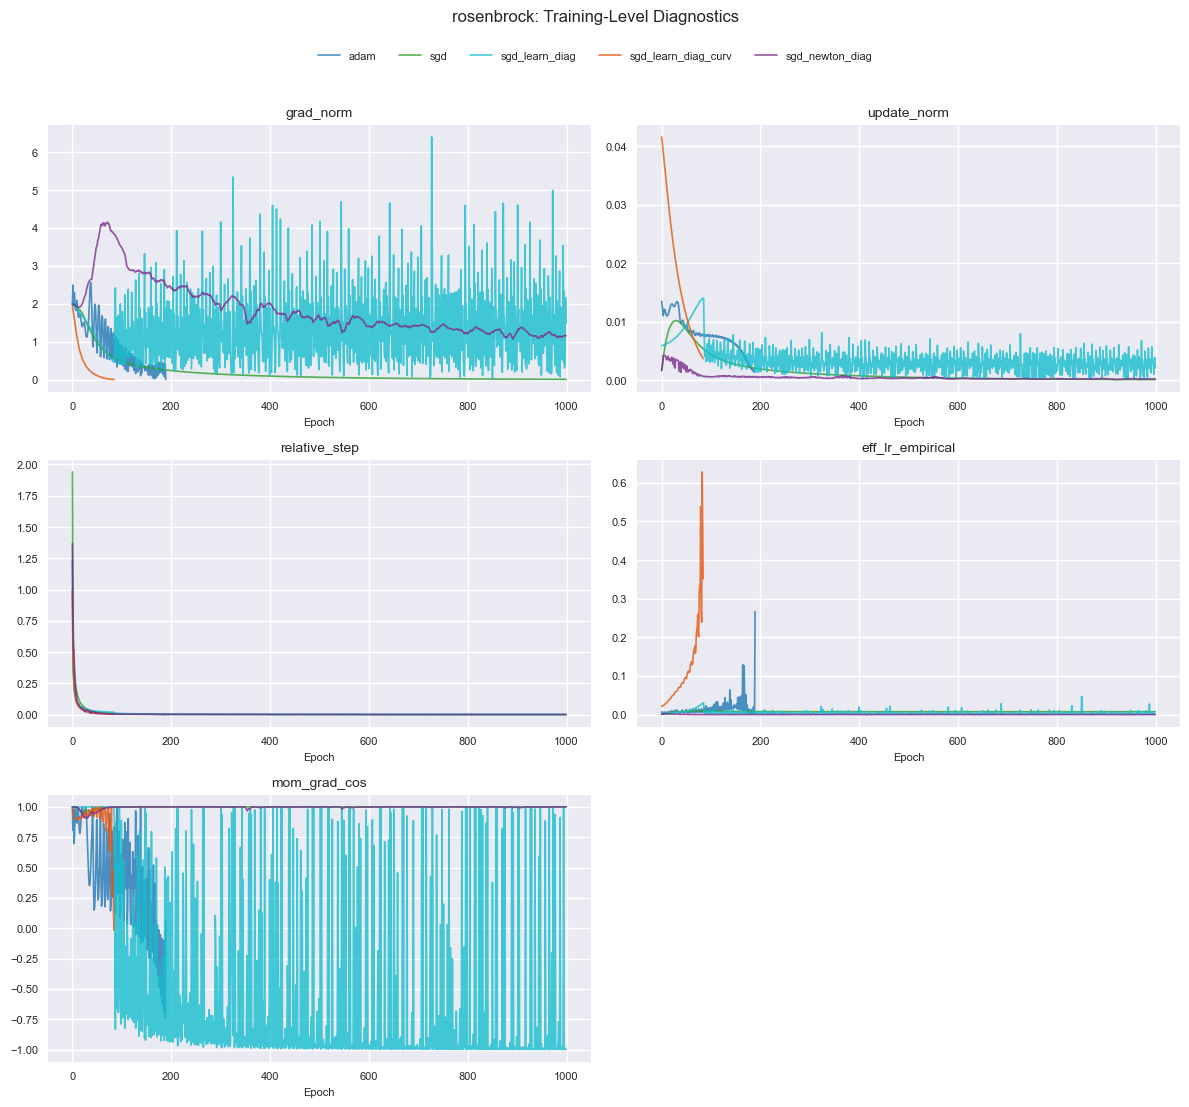

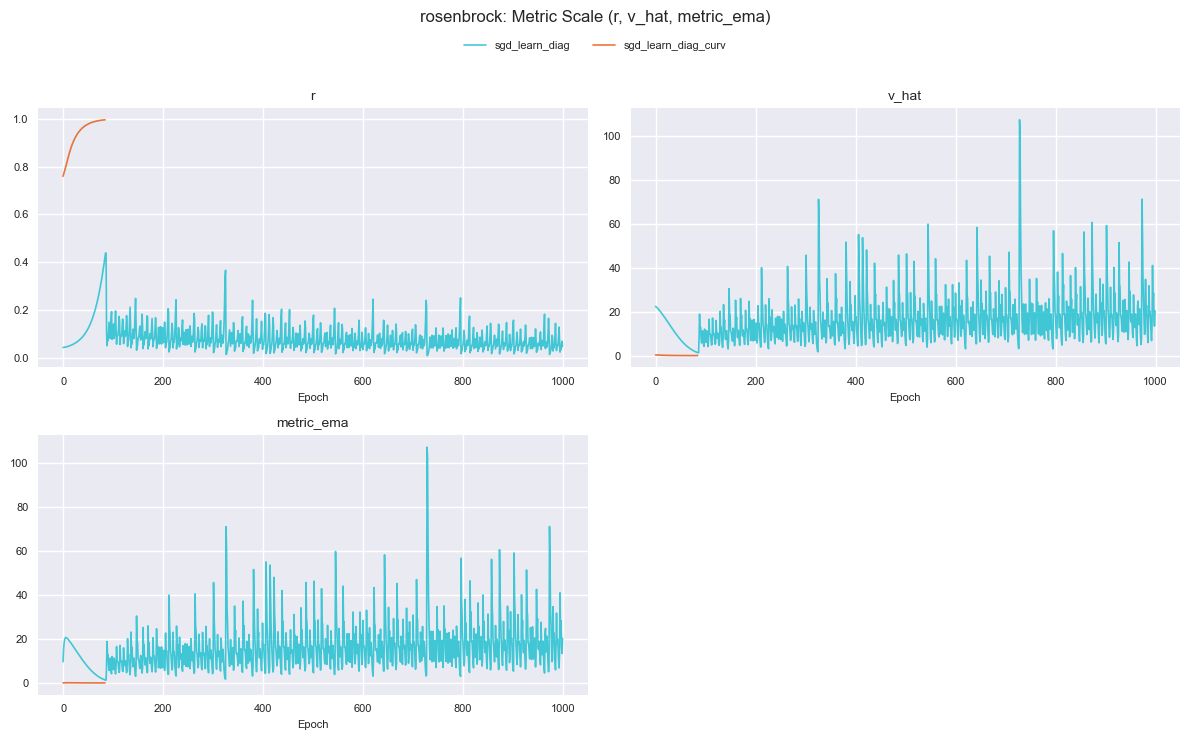

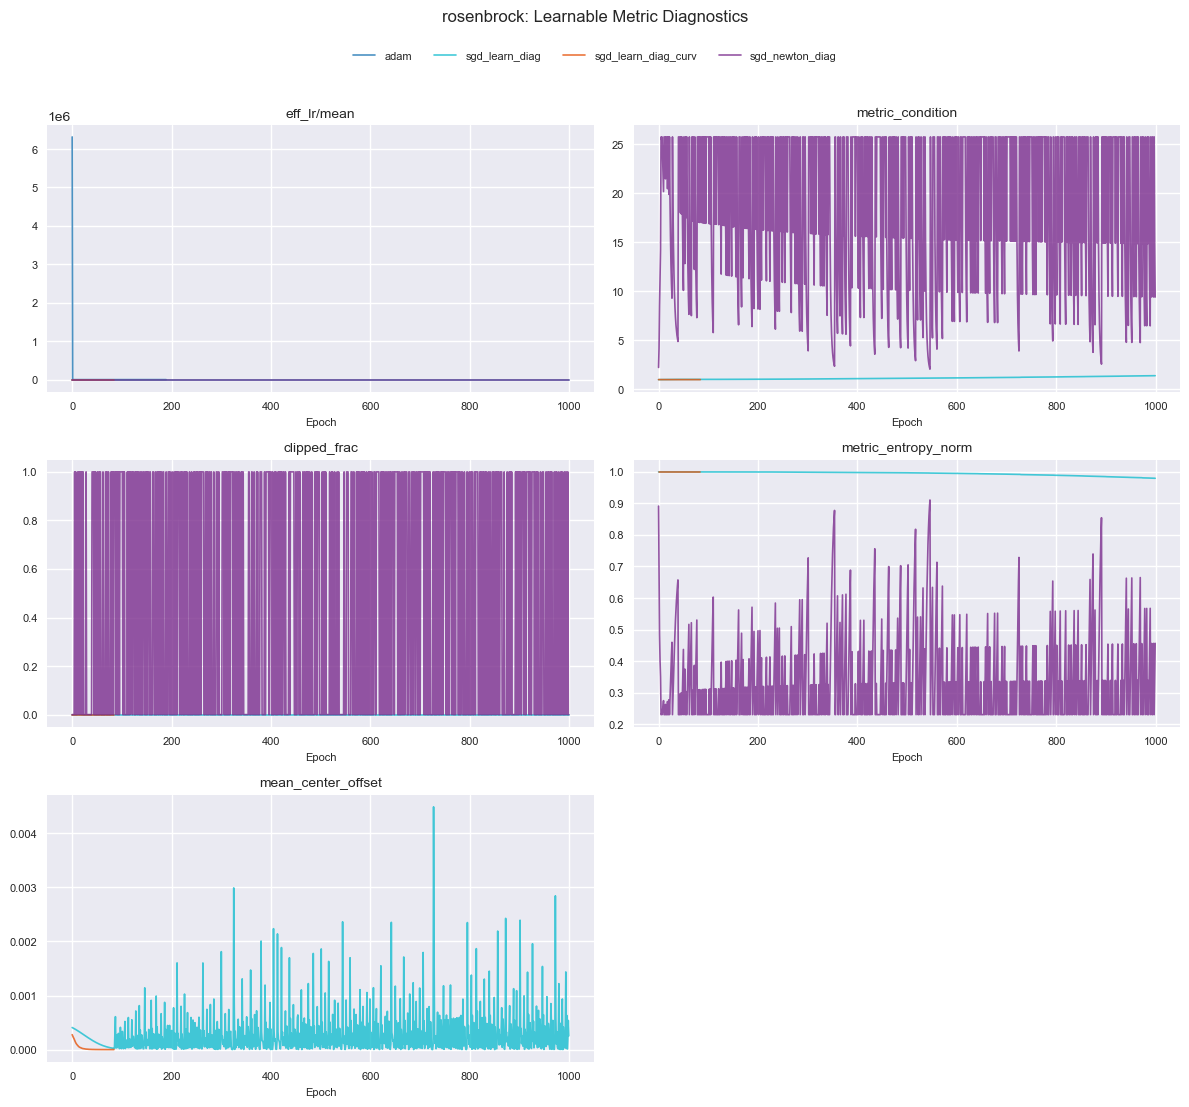

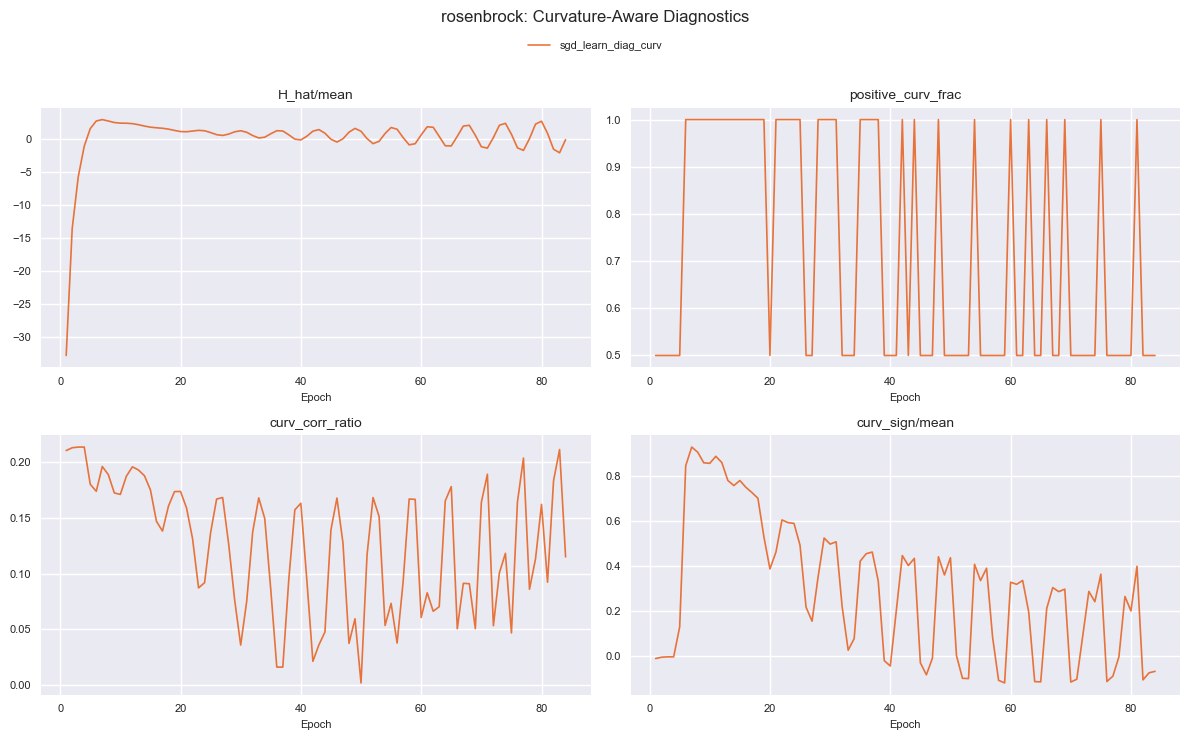

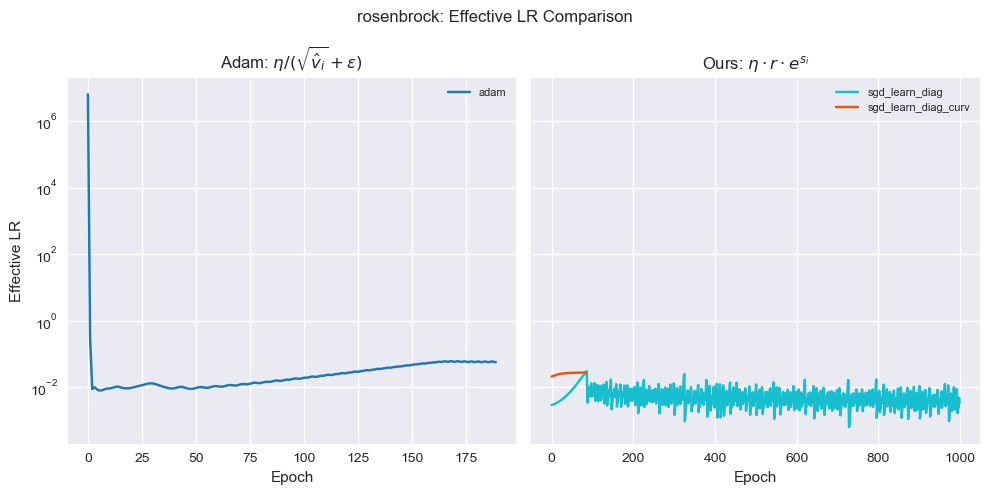

In [8]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_rosenbrock", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="rosenbrock", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for rosenbrock.")

### Himmelblau

  [skip] No data for requested keys in: himmelblau: Off-Diagonal (Woodbury) Diagnostics


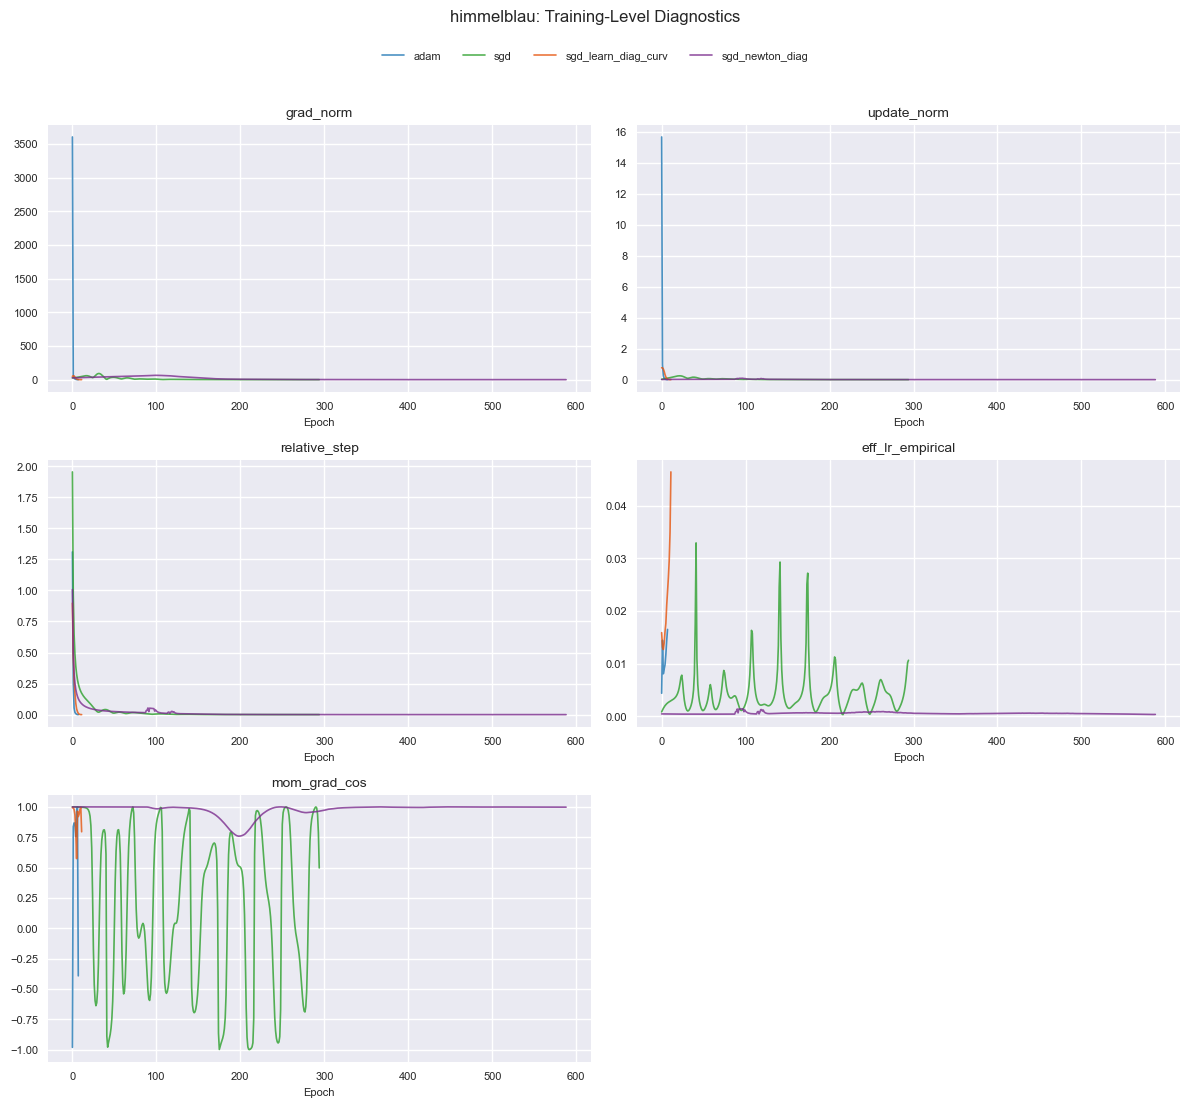

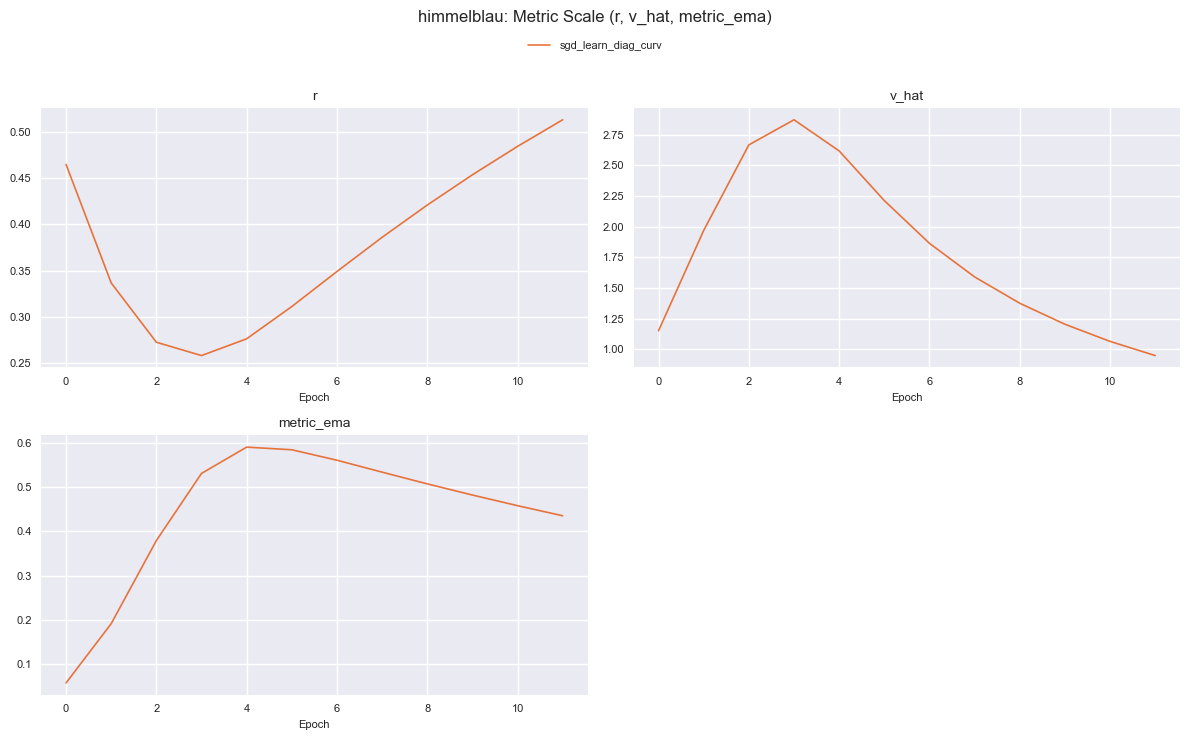

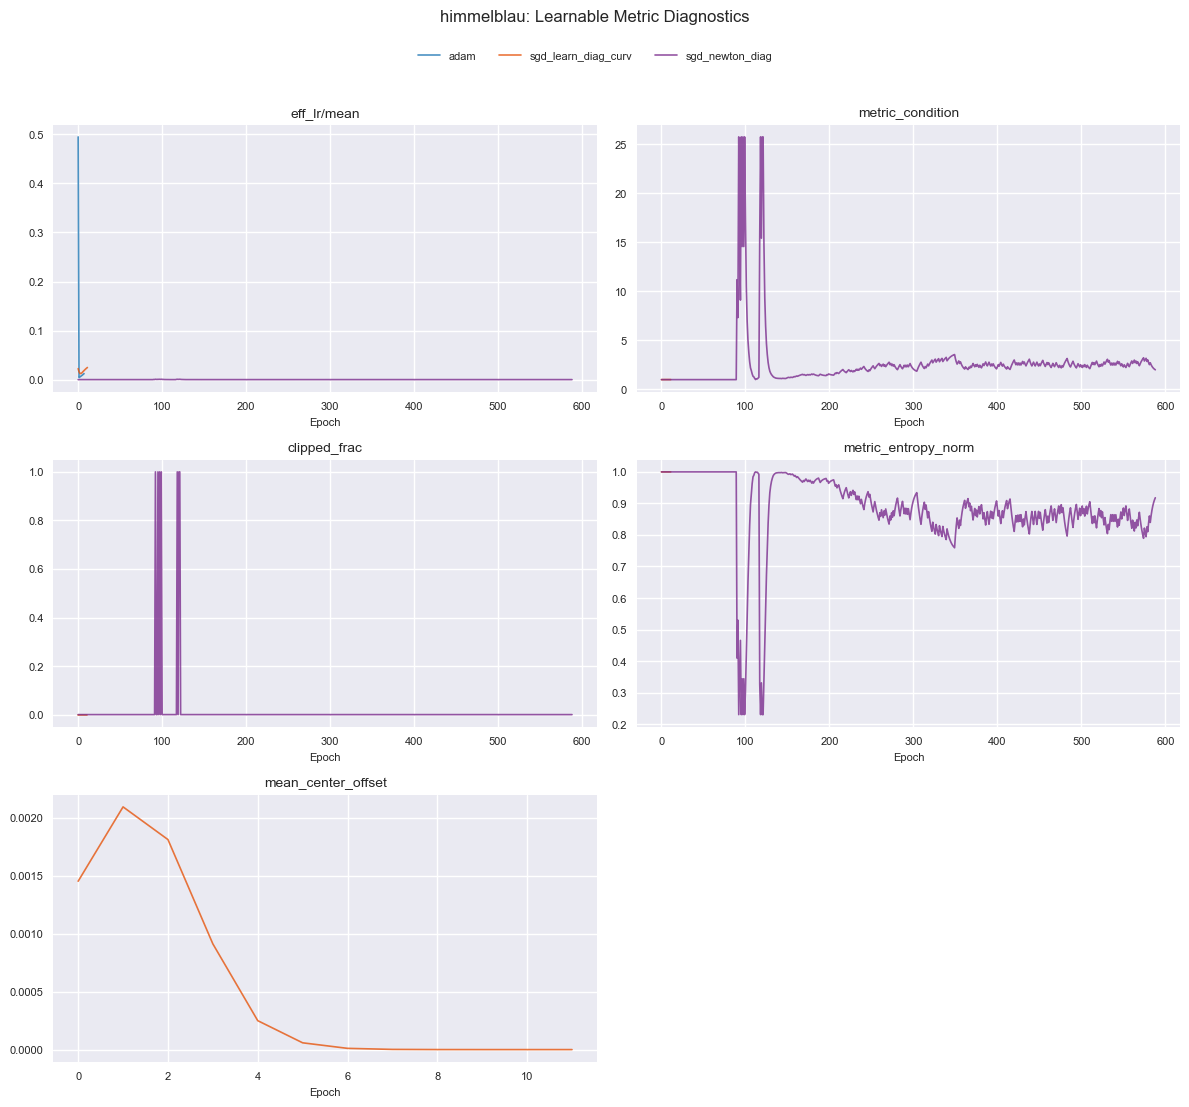

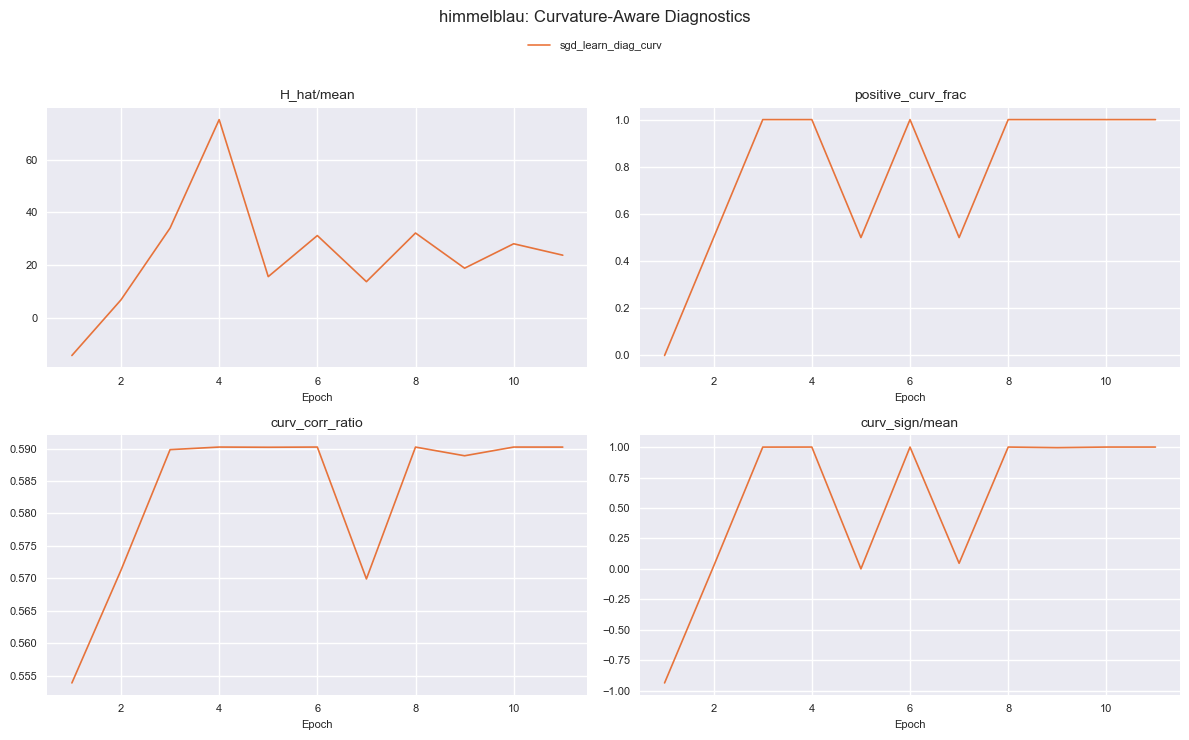

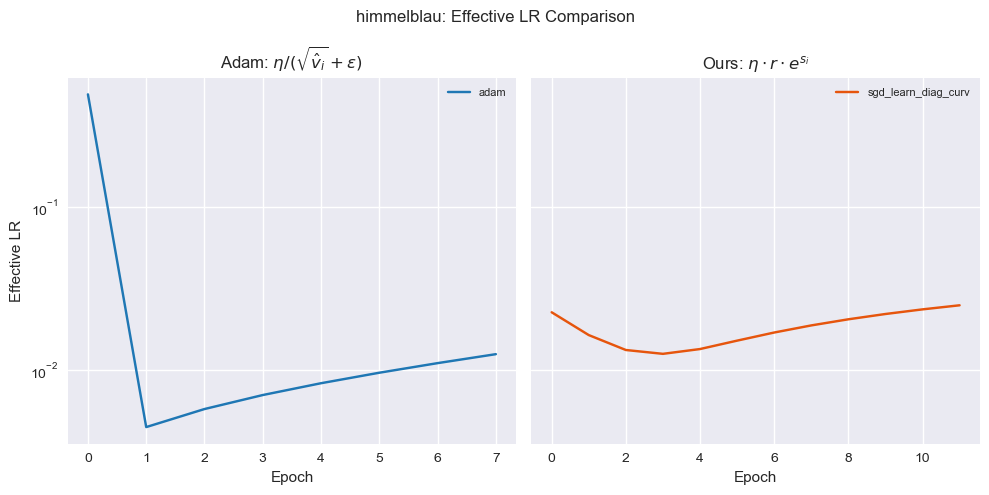

In [9]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_himmelblau", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="himmelblau", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for himmelblau.")

### Ackley

  [skip] No data for requested keys in: ackley: Off-Diagonal (Woodbury) Diagnostics


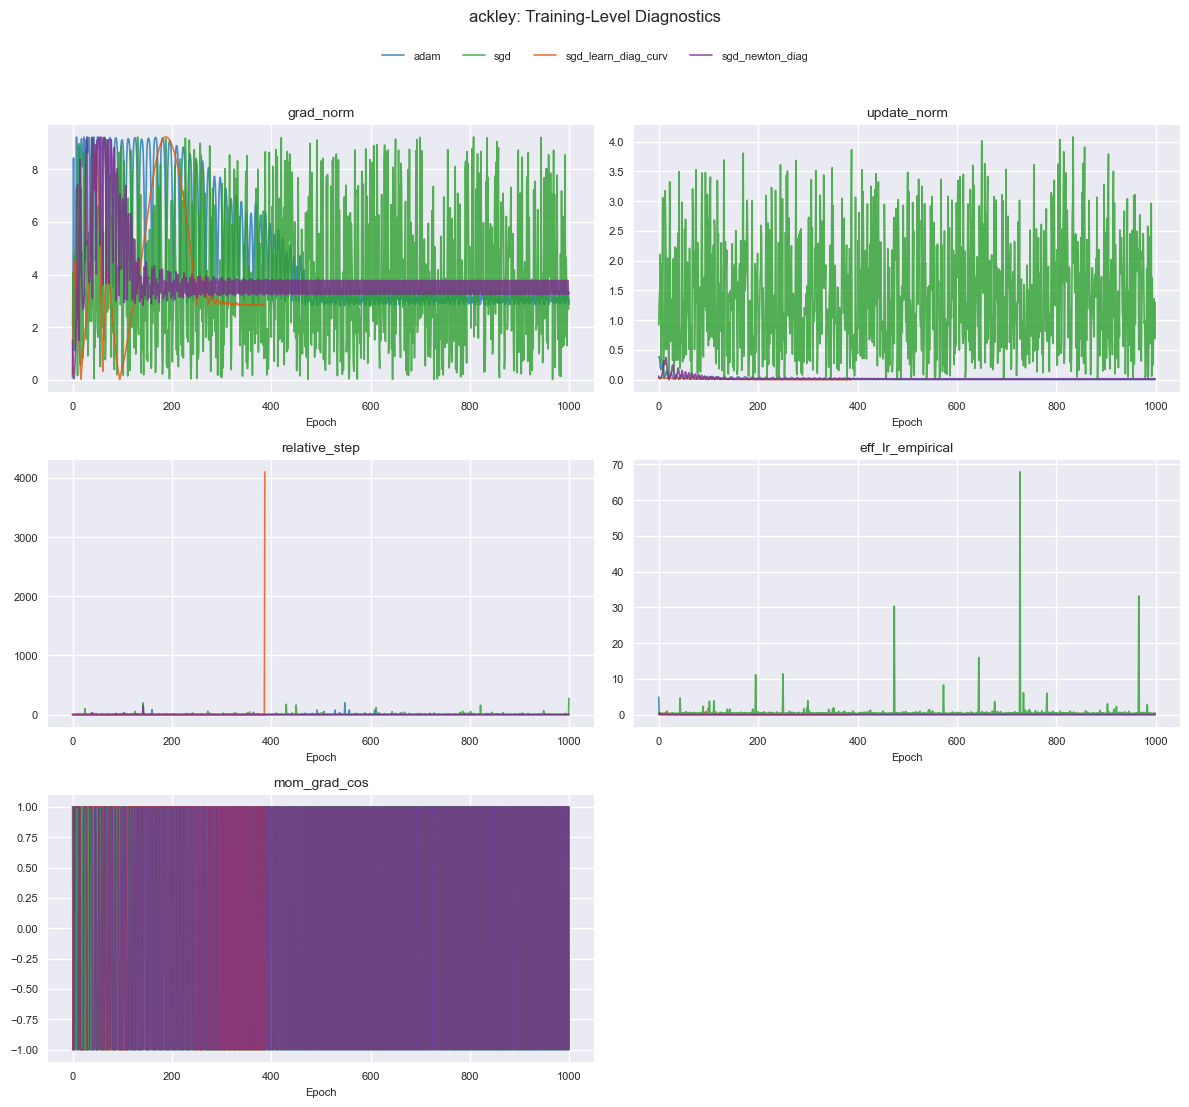

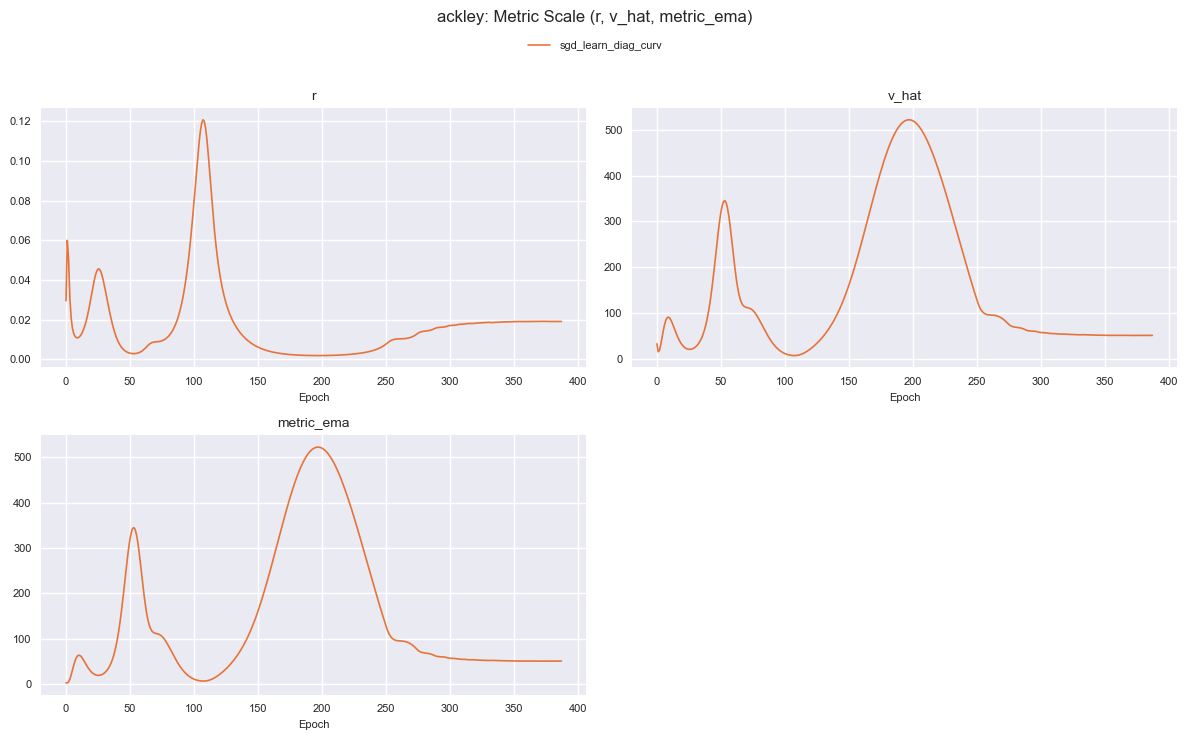

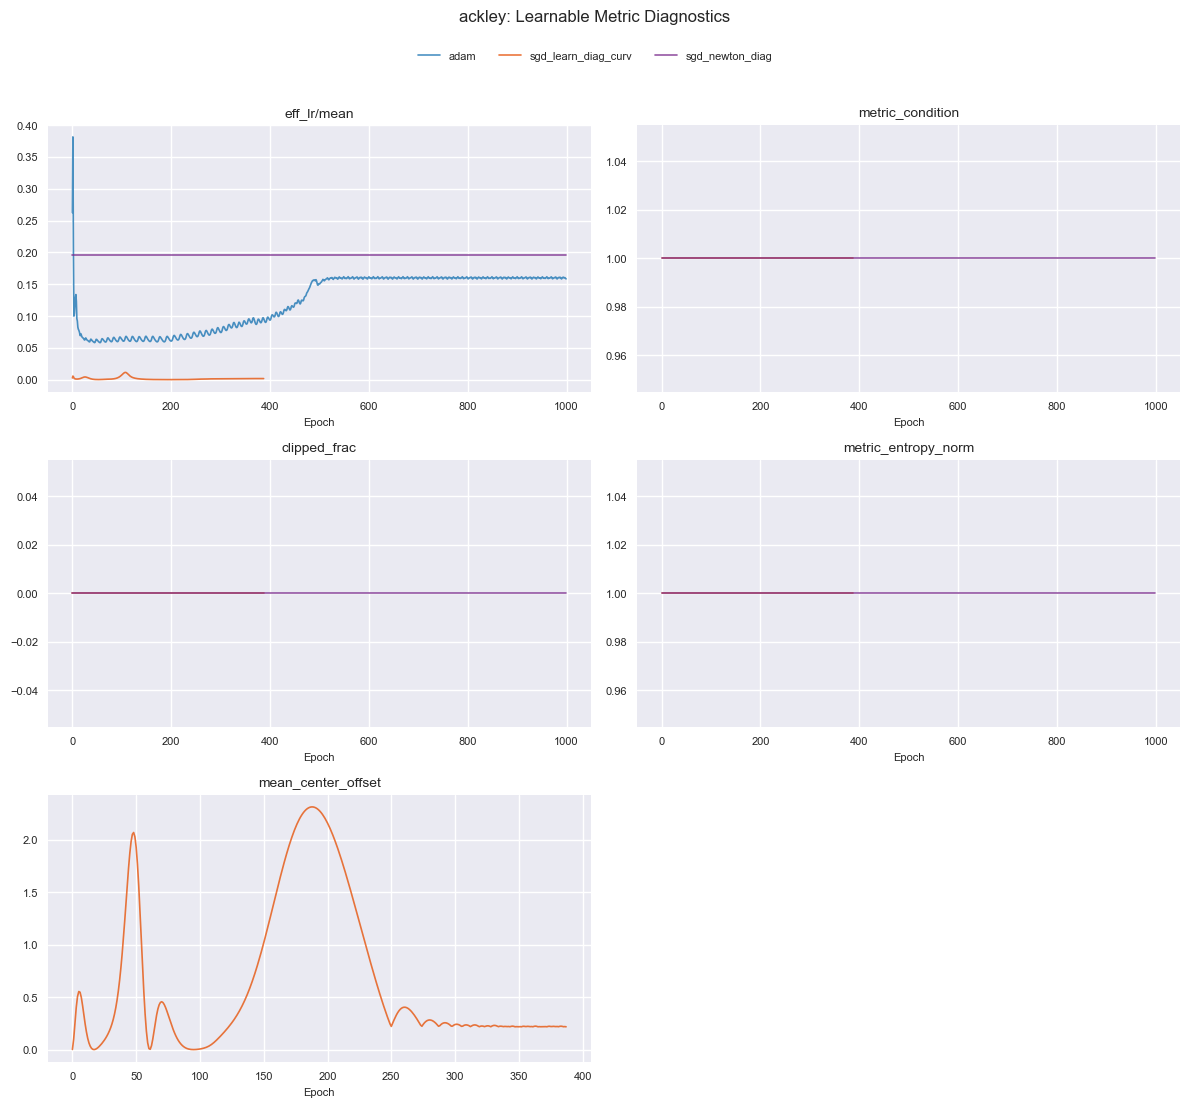

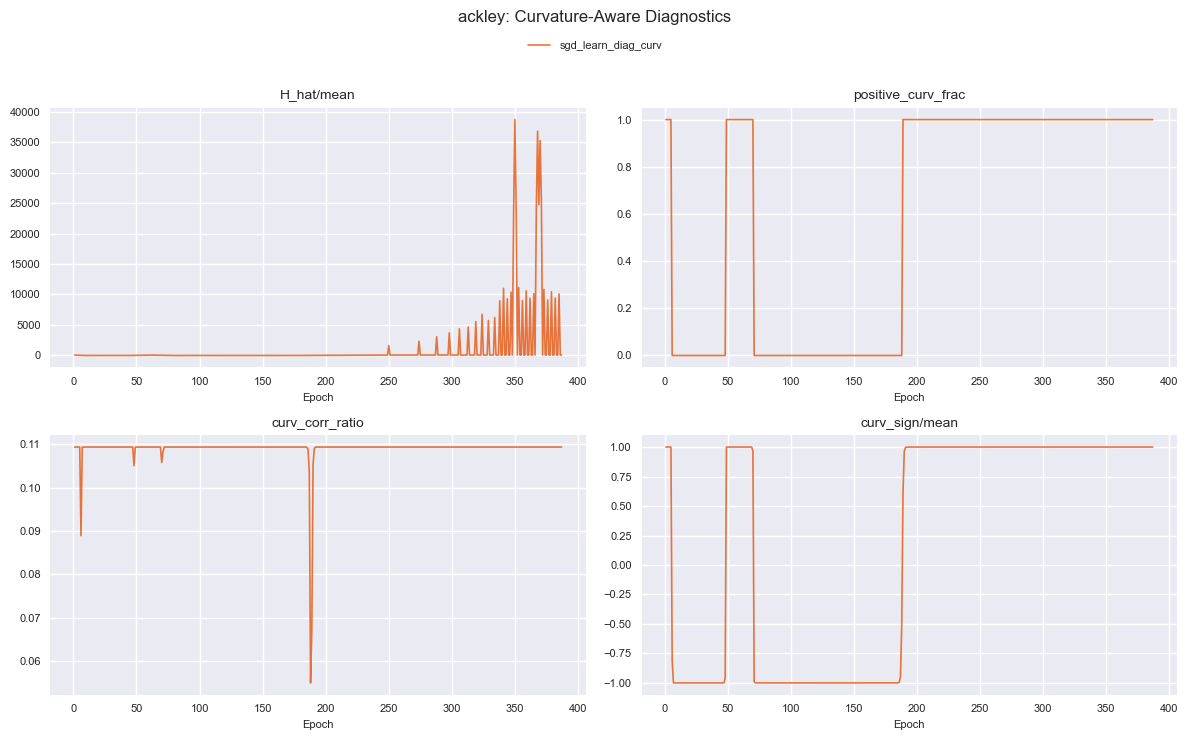

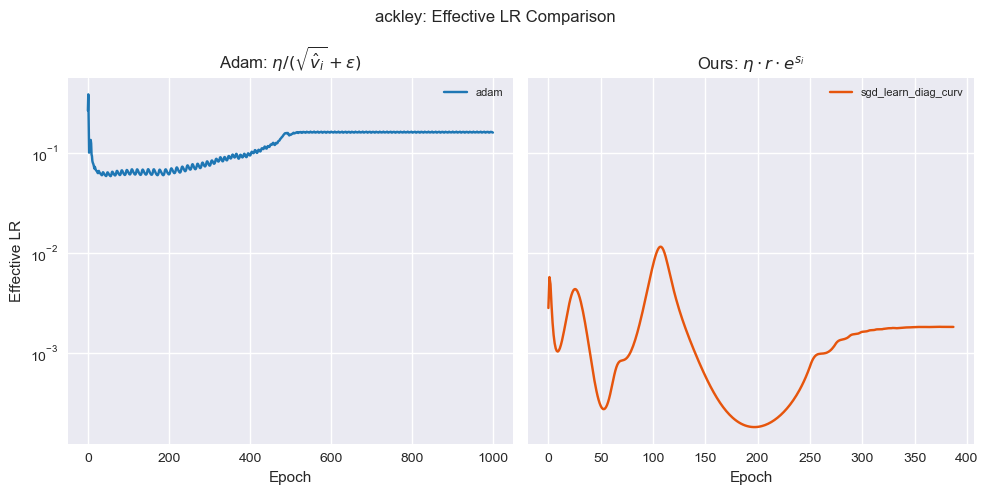

In [10]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_ackley", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="ackley", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for ackley.")

### Rastrigin

  [skip] No data for requested keys in: rastrigin: Off-Diagonal (Woodbury) Diagnostics


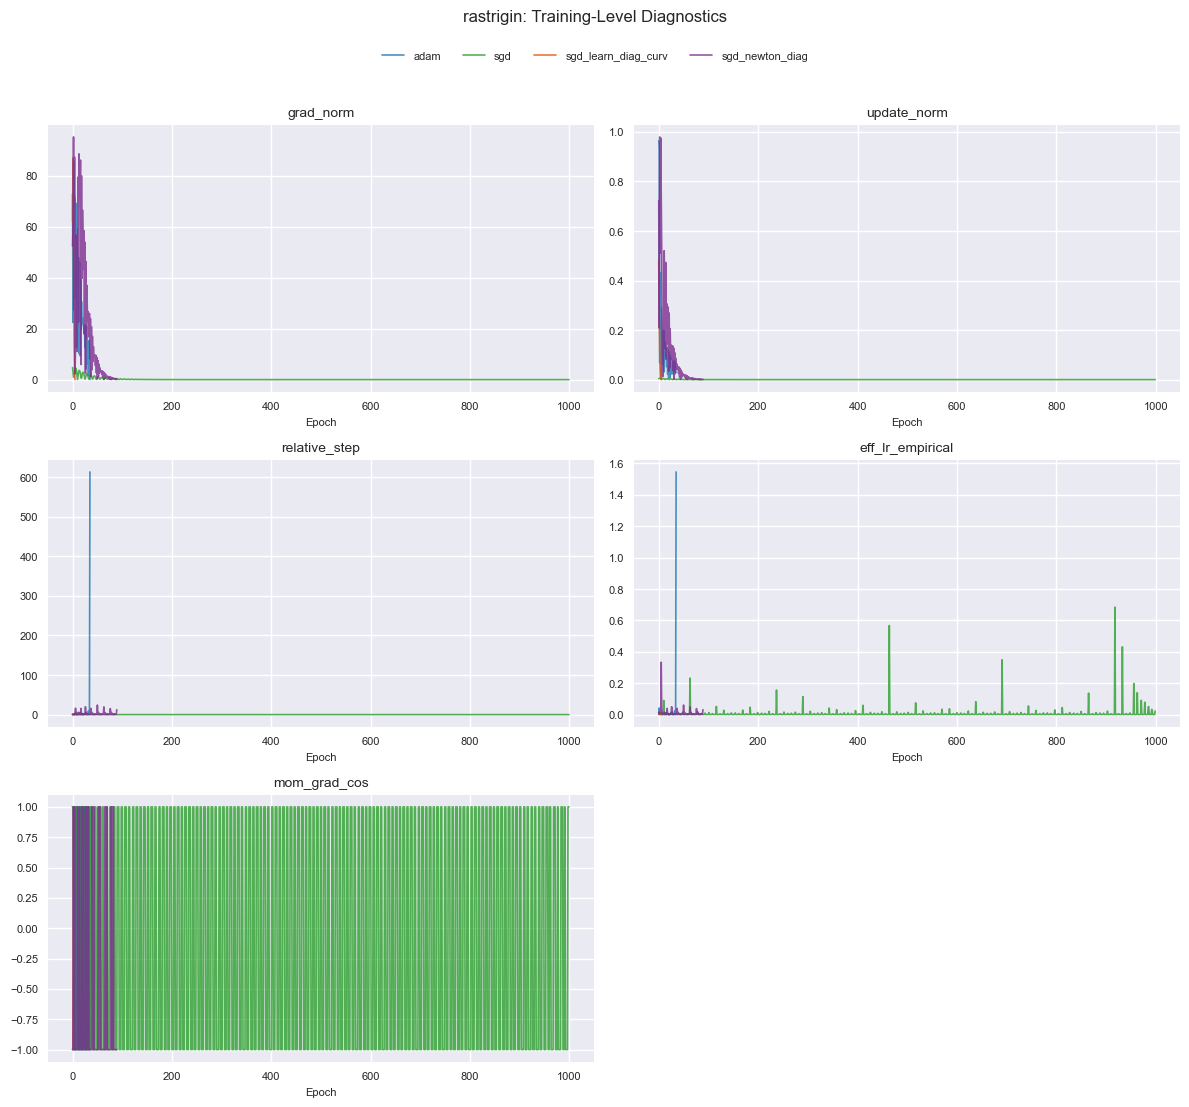

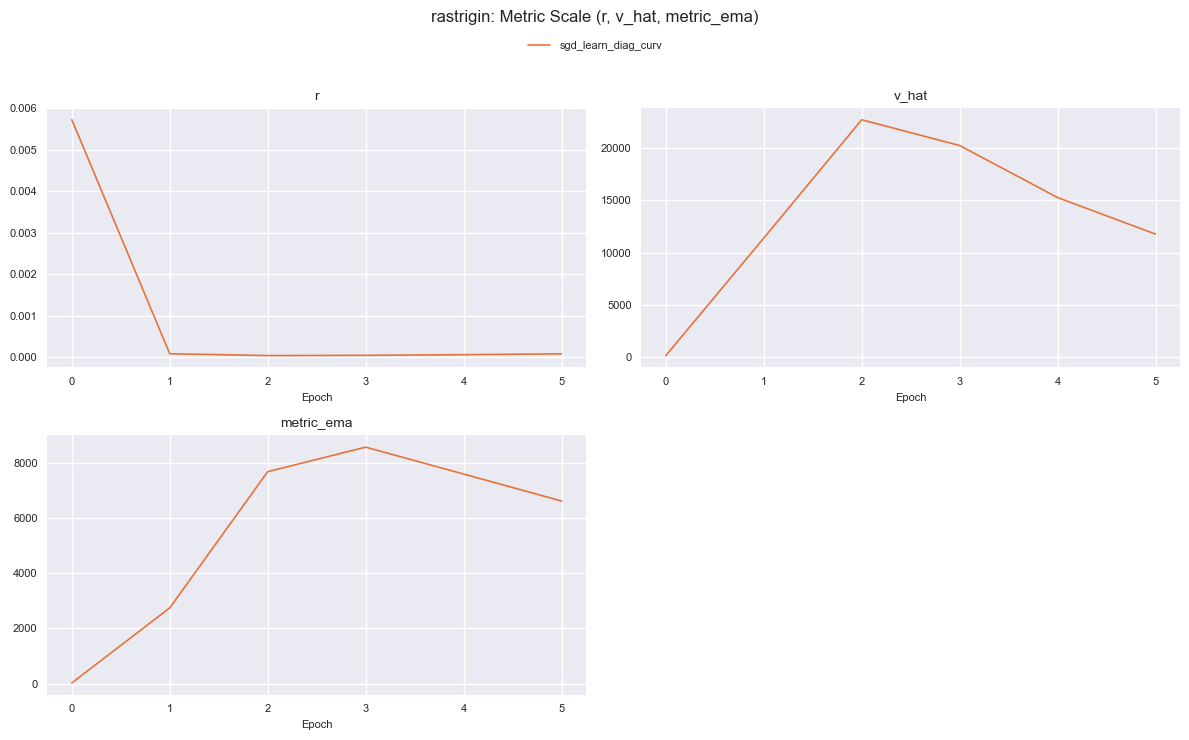

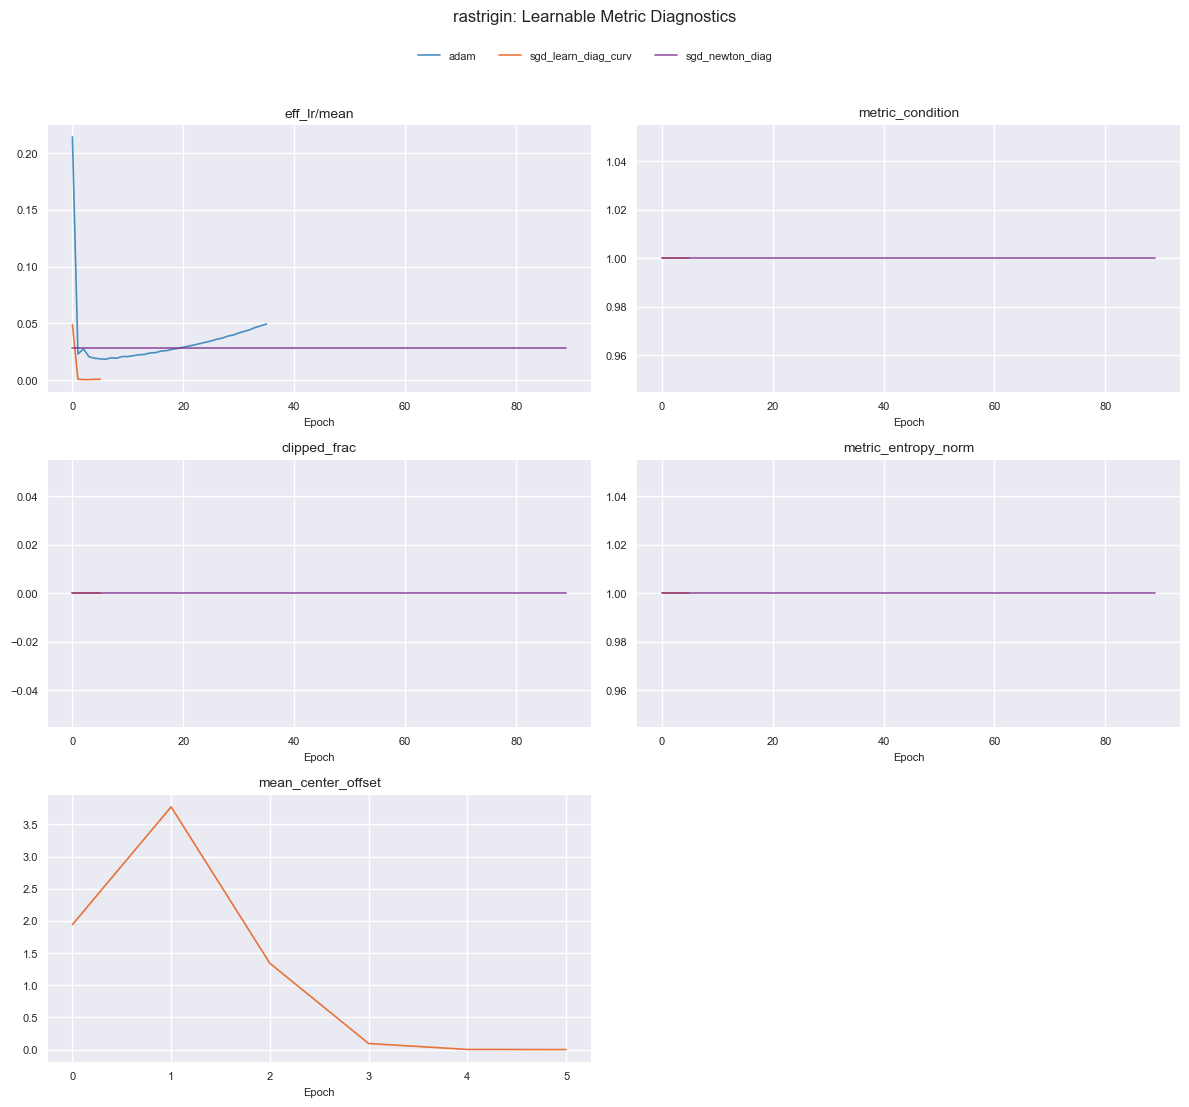

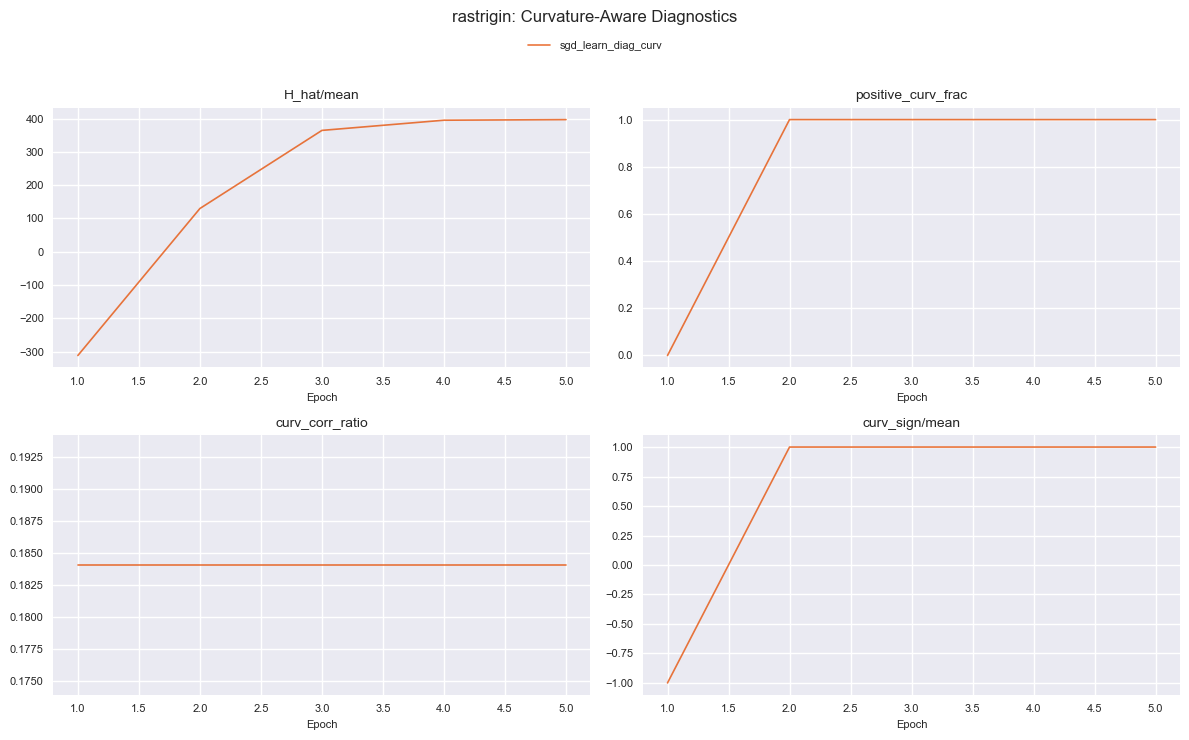

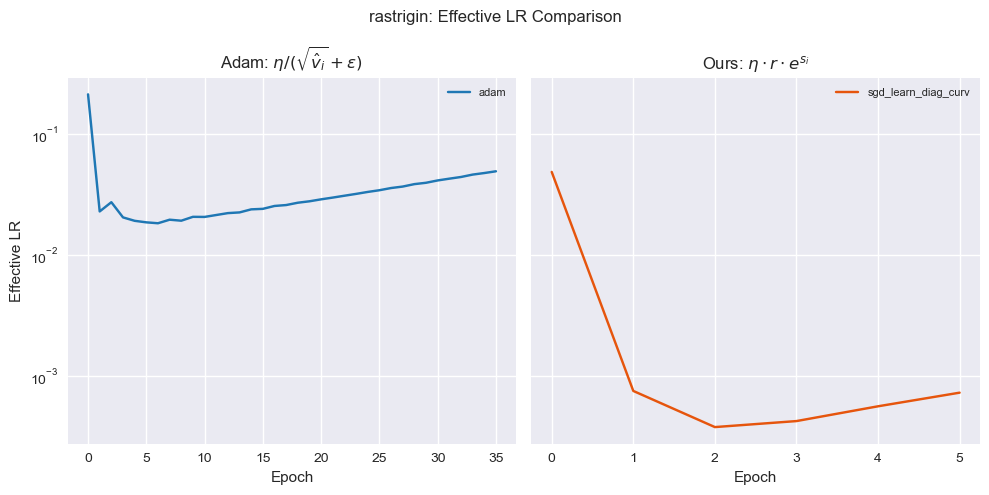

In [11]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_rastrigin", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="rastrigin", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for rastrigin.")

### Styblinski-Tang

  [skip] No data for requested keys in: styblinski_tang: Off-Diagonal (Woodbury) Diagnostics


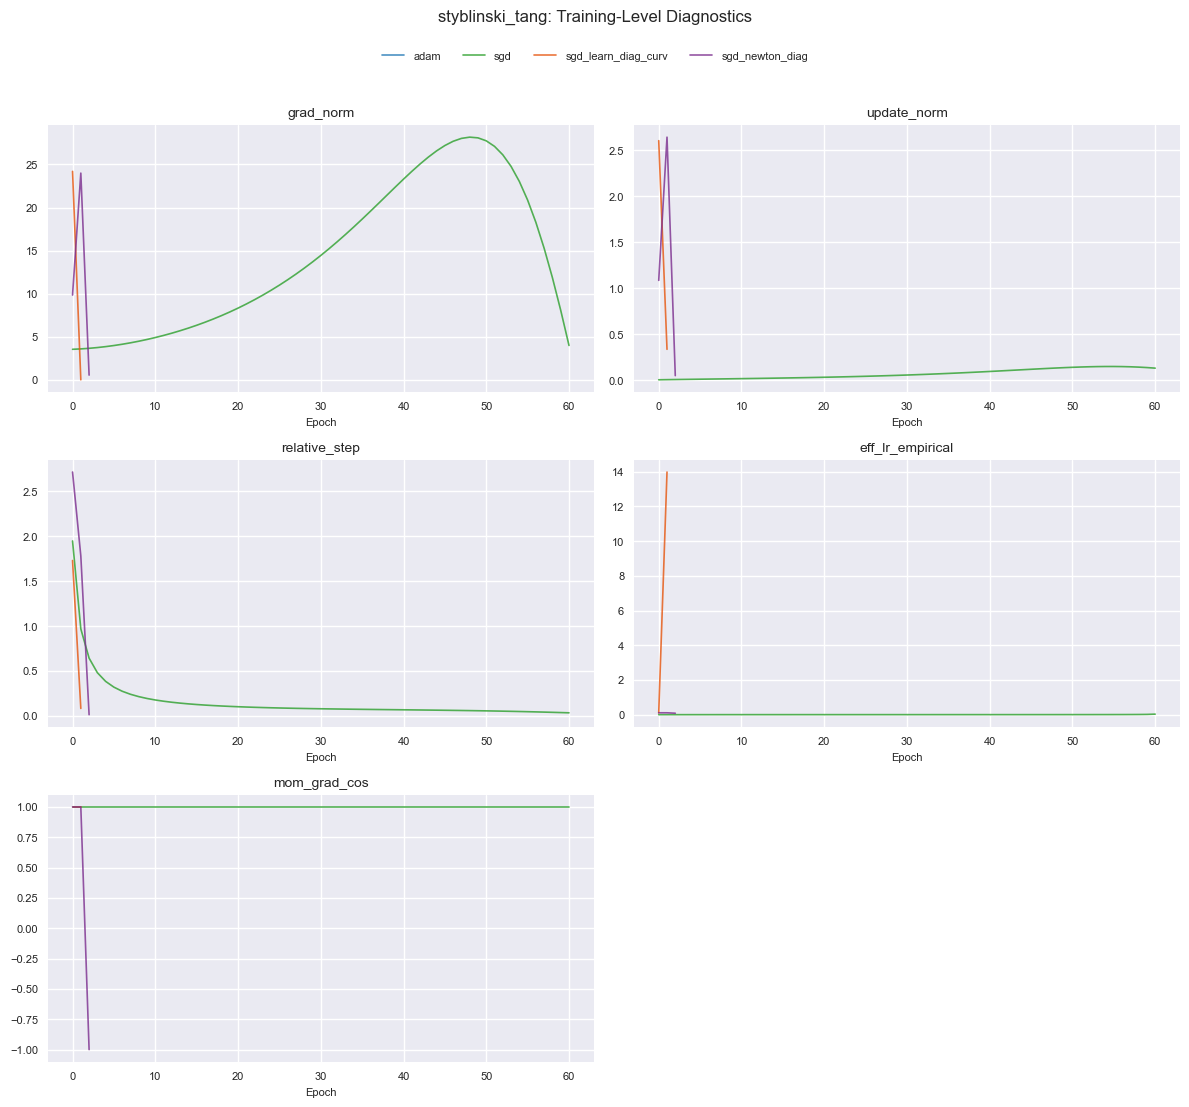

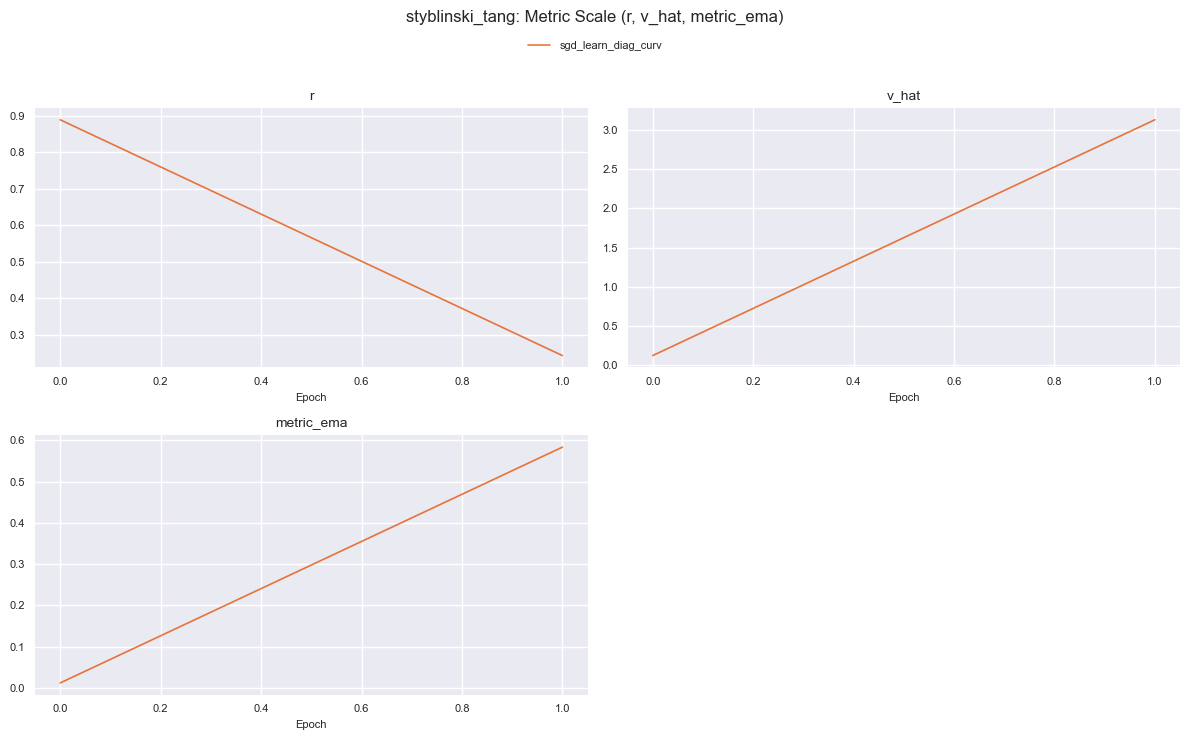

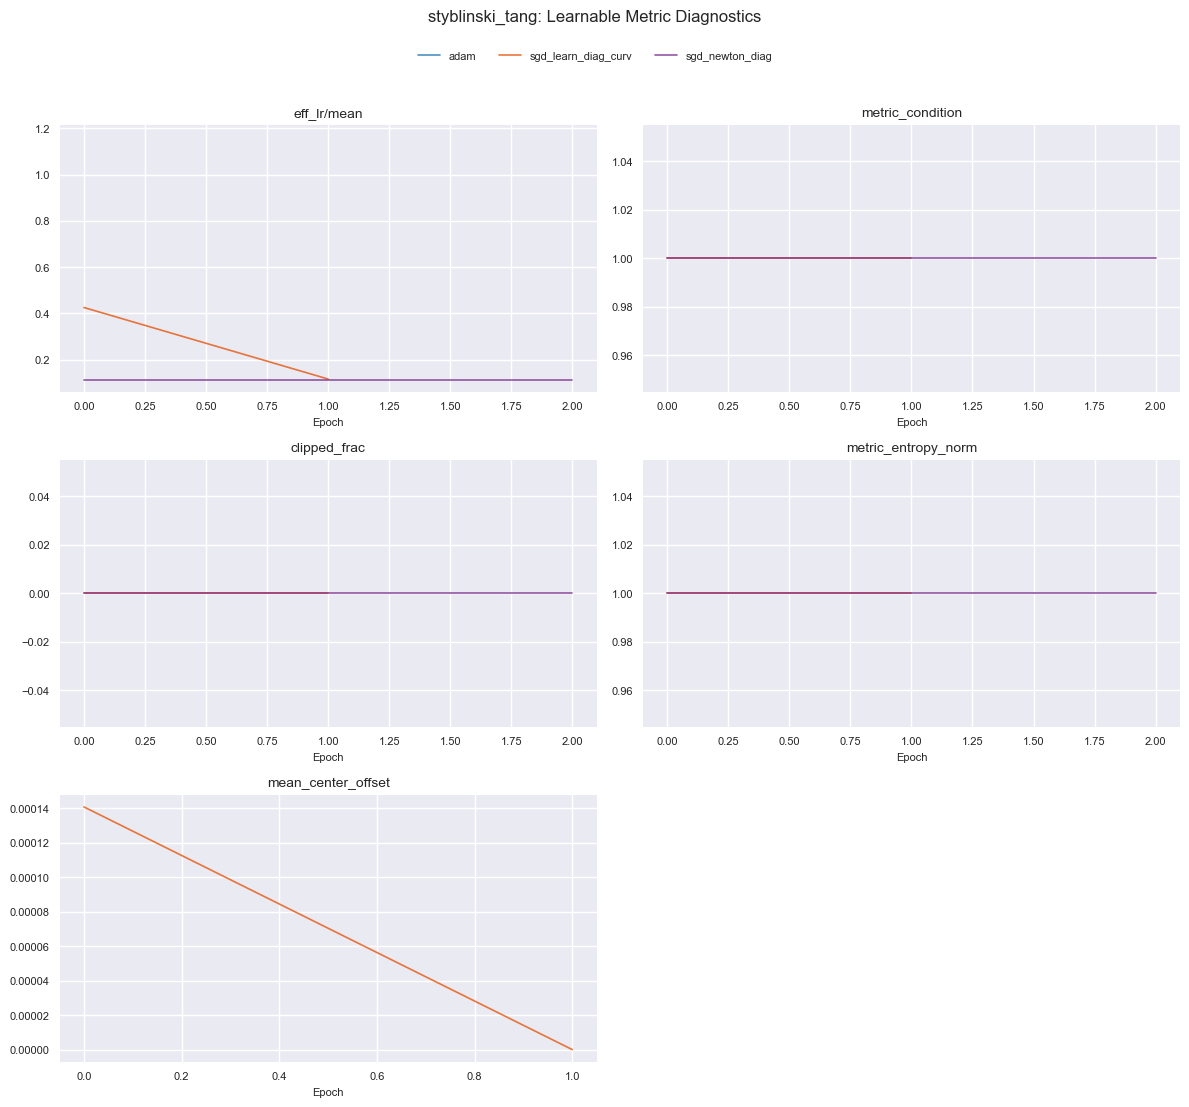

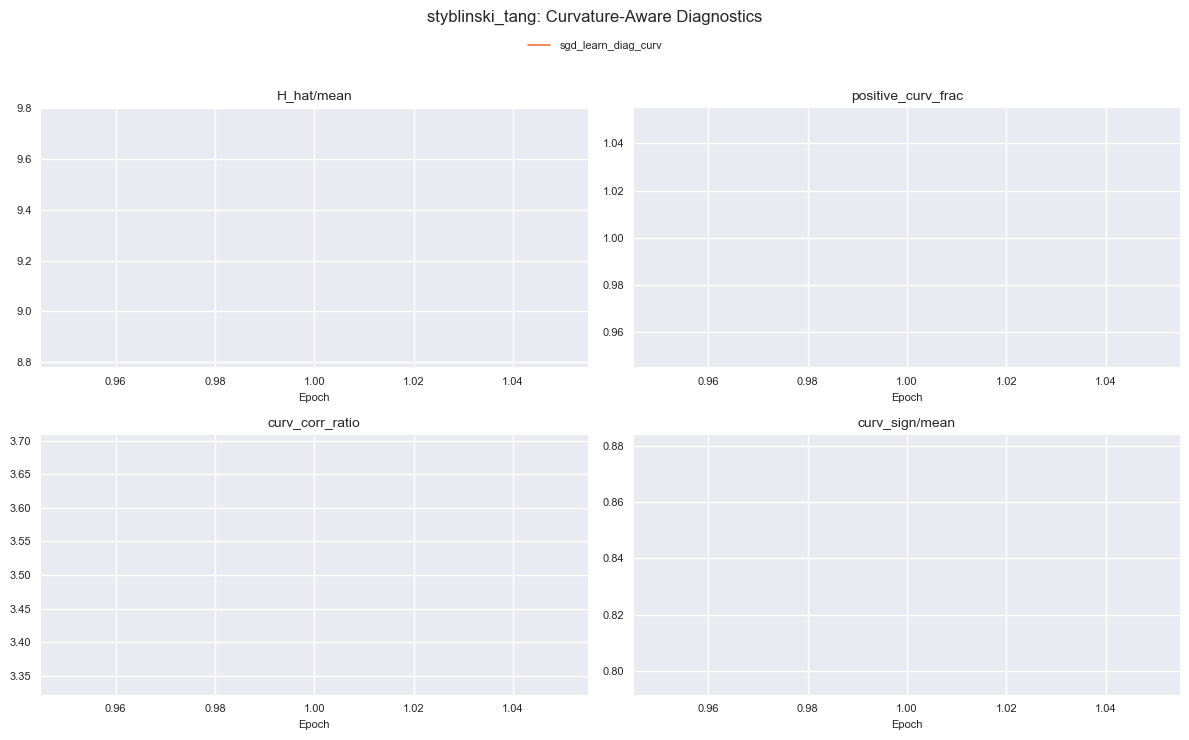

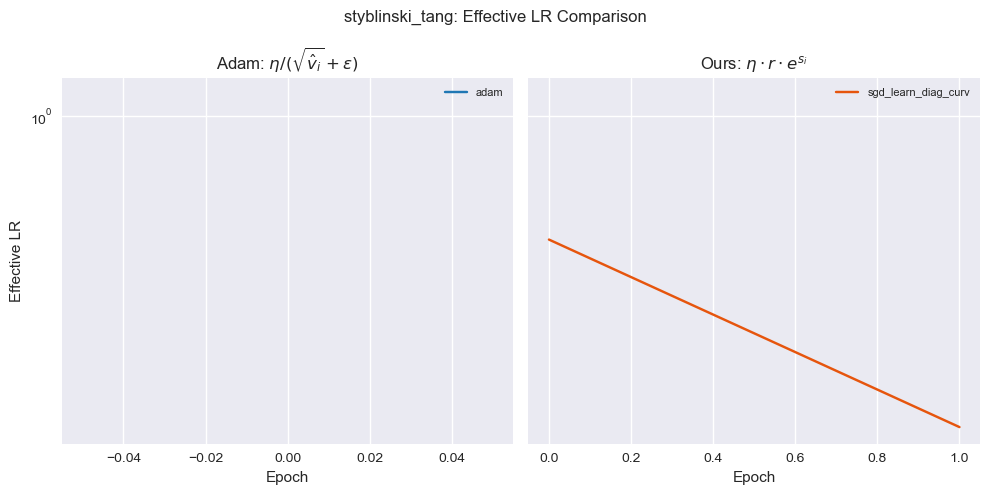

In [12]:
best_runs = _quiet(load_best_runs,
    backend=BACKEND, optimizers=SE_OPTIMIZERS,
    task_tag="small_examples_styblinski_tang", results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=ITERATION_SE,
)
if best_runs:
    diag_data = _quiet(extract_history, BACKEND, best_runs, DIAG_KEYS)
    figs = plot_all_diagnostics(diag_data, title_prefix="styblinski_tang", colors=se_colors)
    for fig, name in figs:
        plt.show()
    if not figs:
        print("No diagnostic data for styblinski_tang.")